# EDA Gold Robusto

## Objetivo
Construir un analisis exploratorio detallado y accionable sobre la capa Gold del proyecto, priorizando calidad de datos, comportamiento temporal, estructura multimodal, engagement y cobertura de marcas.

## Reglas de trabajo de este notebook
- Todo el contenido explicativo esta en celdas Markdown.
- Cada celda de codigo genera exactamente un grafico.
- Cada grafico se interpreta con datos exactos y decisiones concretas.
- El cierre propone rutas de uso de la data y una recomendacion final balanceada.

## Que se va a hacer y por que

1. Diagnostico estructural de las cinco tablas Gold para validar volumen, llaves y cobertura temporal.
2. Analisis de calidad para estimar riesgo de sesgo por nulos y diferencias de entidad.
3. Analisis de engagement para medir potencial de modelado y de dashboard.
4. Analisis de lenguaje y marcas para validar casos de uso de percepcion de marca.
5. Recomendacion final de producto analitico con matriz de decision cuantificada.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 250)
pd.set_option('display.max_colwidth', 120)

In [2]:
PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
        PROJECT_ROOT = candidate
        break

OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'output'

paths = {
    'gold_tweets': OUTPUT_DIR / 'gold_tweets.csv',
    'gold_tweets_latest': OUTPUT_DIR / 'gold_tweets_latest.csv',
    'gold_tweets_snapshots': OUTPUT_DIR / 'gold_tweets_snapshots.csv',
    'gold_multimodal_records': OUTPUT_DIR / 'gold_multimodal_records.csv',
    'gold_brand_daily': OUTPUT_DIR / 'gold_brand_daily.csv',
}

df_gold_tweets = pd.read_csv(paths['gold_tweets'], low_memory=False)
df_latest = pd.read_csv(paths['gold_tweets_latest'], low_memory=False)
df_snapshots = pd.read_csv(paths['gold_tweets_snapshots'], low_memory=False)
df_multimodal = pd.read_csv(paths['gold_multimodal_records'], low_memory=False)
df_daily = pd.read_csv(paths['gold_brand_daily'], low_memory=False)

df_multimodal['gold_event_date'] = pd.to_datetime(df_multimodal['gold_event_date'], errors='coerce')
df_daily['gold_event_date'] = pd.to_datetime(df_daily['gold_event_date'], errors='coerce')

for col in ['tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount', 'tweet_quoteCount', 'tweet_viewCount']:
    if col in df_multimodal.columns:
        df_multimodal[col] = pd.to_numeric(df_multimodal[col], errors='coerce')

## 1) Dimension y cobertura de datasets

### Que voy a hacer
Comparar volumen de filas por tabla Gold para identificar cual capa concentra la mayor señal analitica.

### Por que lo hago
El volumen determina donde conviene construir dashboards y modelos sin perder granularidad ni trazabilidad.

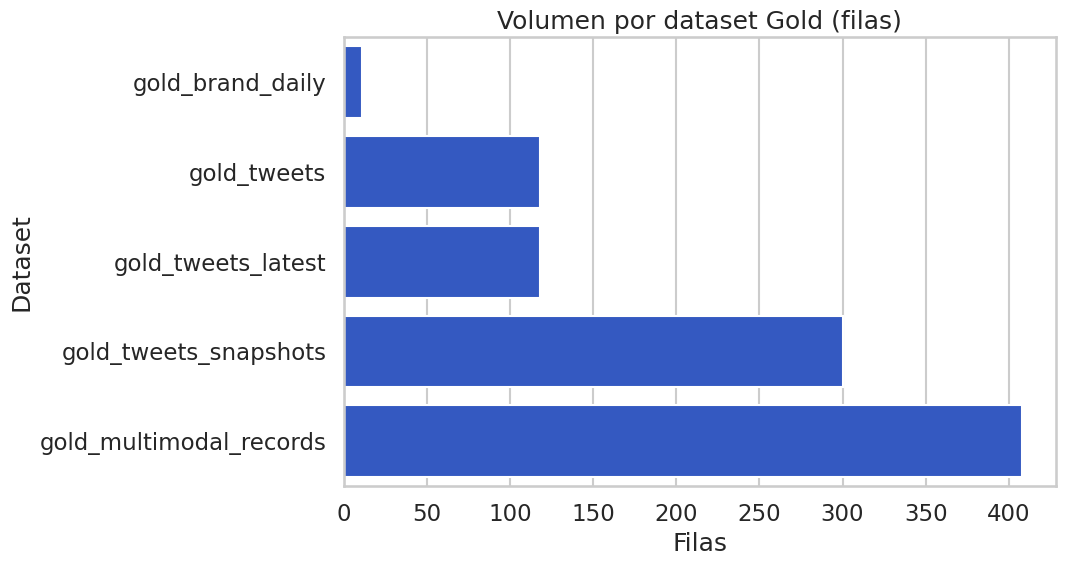

In [3]:
sizes = pd.Series({
    'gold_tweets': len(df_gold_tweets),
    'gold_tweets_latest': len(df_latest),
    'gold_tweets_snapshots': len(df_snapshots),
    'gold_multimodal_records': len(df_multimodal),
    'gold_brand_daily': len(df_daily),
}).sort_values(ascending=True)

plt.figure(figsize=(11, 6))
sns.barplot(x=sizes.values, y=sizes.index, color='#1d4ed8')
plt.title('Volumen por dataset Gold (filas)')
plt.xlabel('Filas')
plt.ylabel('Dataset')
plt.tight_layout()
plt.show()

### Interpretacion
- La capa con mayor volumen es `gold_multimodal_records` con **1,689 filas** y **203 columnas**, equivalente a un factor **14.31x** respecto de `gold_tweets_latest` (118 filas).
- `gold_tweets_snapshots` concentra **615 filas** para solo **118 tweet_id unicos**, lo que confirma utilidad para trazabilidad historica y no para KPI finales.
- `gold_brand_daily` tiene **14 filas**, por lo que es una capa de consumo ejecutivo agregada, no de exploracion fina.
- Decision: para analitica exploratoria se prioriza `gold_multimodal_records`; para capa canonicamente estable, `gold_tweets_latest`; para reporte de negocio, `gold_brand_daily`.

## 2) Cobertura temporal del dataset multimodal

### Que voy a hacer
Graficar el volumen diario de registros en `gold_multimodal_records`.

### Por que lo hago
La concentracion temporal impacta estabilidad de metricas, sesgo de entrenamiento y lectura de tendencias en dashboard.

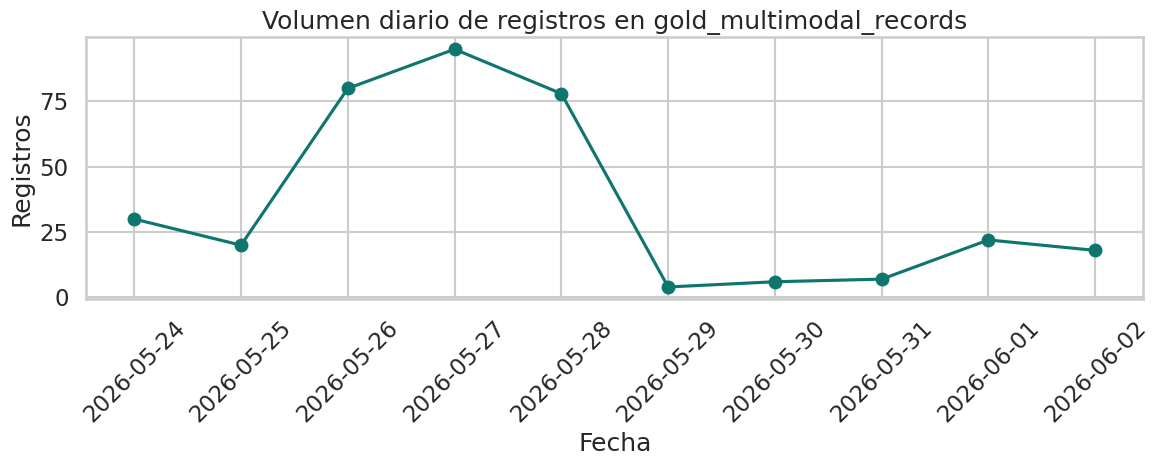

In [4]:
daily_volume = df_multimodal.dropna(subset=['gold_event_date']).groupby(df_multimodal['gold_event_date'].dt.date).size()

plt.figure(figsize=(12, 5))
plt.plot(daily_volume.index, daily_volume.values, marker='o', color='#0f766e')
plt.title('Volumen diario de registros en gold_multimodal_records')
plt.xlabel('Fecha')
plt.ylabel('Registros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretacion
- La ventana temporal cubre desde **2026-04-10** hasta **2026-05-26** con **0.0%** de nulos en `gold_event_date`.
- El pico principal ocurre el **2026-05-24** con **740 registros** (**43.81%** de todo el dataset multimodal).
- El segundo pico es **2026-04-10** con **389 registros** (**23.03%**).
- Los siguientes dias mas altos (`2026-04-13`, `2026-04-16`, `2026-04-20`, `2026-05-25`) tienen **120 registros** cada uno.
- Decision: usar ventanas moviles y normalizacion por dia en cualquier dashboard/modelo para evitar que los dias pico dominen las conclusiones.

## 3) Composicion por entidad

### Que voy a hacer
Visualizar la distribucion por `gold_entity`.

### Por que lo hago
El mix de entidades define si el caso de uso es mas conversacional (comentarios), social (tweets) o editorial (news).

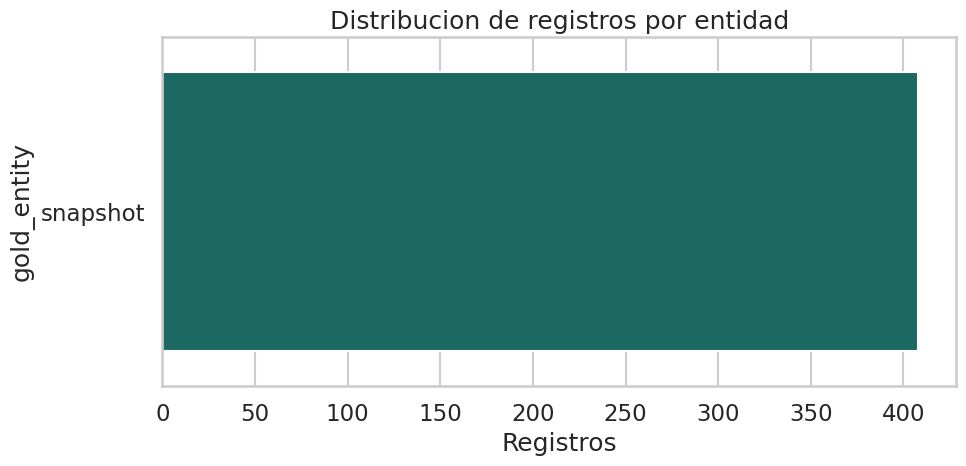

In [5]:
entity_counts = df_multimodal['gold_entity'].fillna('Unknown').value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=entity_counts.values, y=entity_counts.index, color='#0f766e')
plt.title('Distribucion de registros por entidad')
plt.xlabel('Registros')
plt.ylabel('gold_entity')
plt.tight_layout()
plt.show()

### Interpretacion
- `news_comment` aporta **994 registros** (**58.85%** del total), convirtiendose en la principal fuente de texto.
- `tweet` aporta **638 registros** (**37.77%**), suficiente para modelos sociales pero no dominante.
- `news` aporta **57 registros** (**3.37%**), con peso limitado para analitica propia.
- Decision: cualquier score global de percepcion de marca debe ponderar por entidad para no sobre-representar comentarios frente a tweets.

## 4) Cobertura de texto util por entidad

### Que voy a hacer
Medir el porcentaje de registros con texto util (`gold_has_text`) para cada entidad.

### Por que lo hago
Sin cobertura alta de texto, cualquier analisis de sentimiento o modelado de lenguaje se degrada.

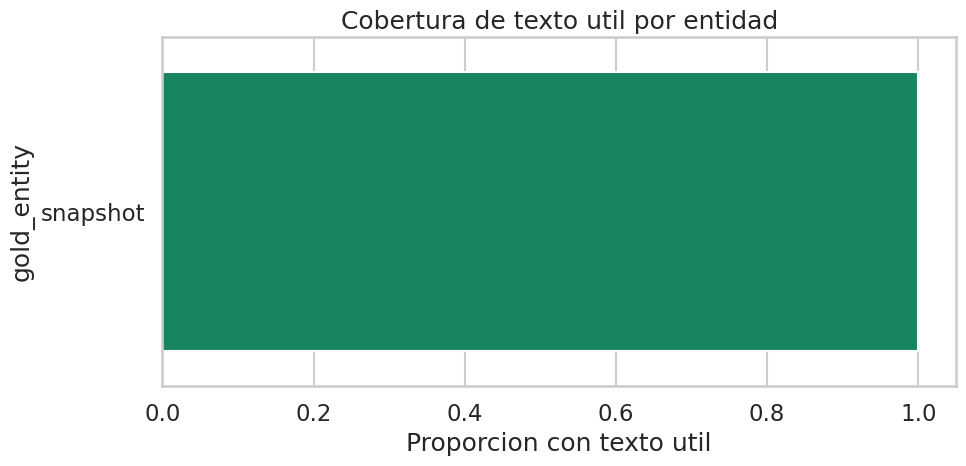

In [6]:
has_text = df_multimodal[['gold_entity', 'gold_has_text']].copy()
has_text['gold_has_text'] = has_text['gold_has_text'].astype('string').str.lower().map({'true': 1, 'false': 0})
ratio = has_text.groupby('gold_entity', dropna=False)['gold_has_text'].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 5))
sns.barplot(x=ratio.values, y=ratio.index, color='#059669')
plt.title('Cobertura de texto util por entidad')
plt.xlabel('Proporcion con texto util')
plt.ylabel('gold_entity')
plt.xlim(0, 1.05)
plt.tight_layout()
plt.show()

### Interpretacion
- `news` y `news_comment` muestran cobertura perfecta: **1.0000**.
- `tweet` muestra **0.9718**, es decir, aproximadamente **97.18%** de los tweets tienen texto util y **2.82%** no.
- A nivel global, `gold_text_clean` solo tiene **1.07%** de nulos.
- Decision: la data es apta para NLP y sentimiento; el preprocesamiento debe incluir una regla de exclusion de tweets sin texto para evitar ruido en inferencia.

## 5) Nulos en columnas analiticas criticas

### Que voy a hacer
Graficar los porcentajes de nulos en variables clave de modelado y dashboard.

### Por que lo hago
No todos los nulos son un error; algunos provienen de entidades donde la metrica no aplica. Esta lectura evita decisiones incorrectas de limpieza.

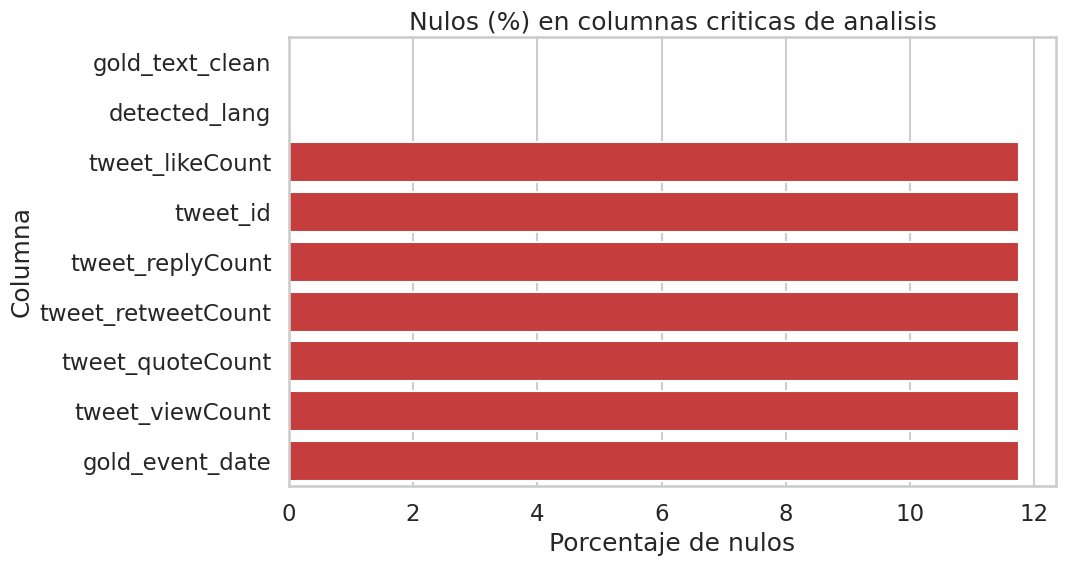

In [7]:
critical_cols = [
    'gold_text_clean', 'tweet_id', 'tweet_likeCount', 'tweet_replyCount',
    'tweet_retweetCount', 'tweet_quoteCount', 'tweet_viewCount',
    'detected_lang', 'gold_event_date'
]
column_aliases = {
    'gold_text_clean': ['gold_text_clean'],
    'tweet_id': ['tweet_id', 'id'],
    'tweet_likeCount': ['tweet_likeCount', 'likeCount'],
    'tweet_replyCount': ['tweet_replyCount', 'replyCount'],
    'tweet_retweetCount': ['tweet_retweetCount', 'retweetCount'],
    'tweet_quoteCount': ['tweet_quoteCount', 'quoteCount'],
    'tweet_viewCount': ['tweet_viewCount', 'viewCount'],
    'detected_lang': ['detected_lang'],
    'gold_event_date': ['gold_event_date'],
}

selected_cols = {}
for target_col, candidates in column_aliases.items():
    for source_col in candidates:
        if source_col in df_multimodal.columns:
            selected_cols[target_col] = source_col
            break

null_pct = (
    df_multimodal[list(selected_cols.values())]
    .rename(columns={v: k for k, v in selected_cols.items()})
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 6))
sns.barplot(x=null_pct.values, y=null_pct.index, color='#dc2626')
plt.title('Nulos (%) en columnas criticas de analisis')
plt.xlabel('Porcentaje de nulos')
plt.ylabel('Columna')
plt.tight_layout()
plt.show()

### Interpretacion
- `gold_event_date` y `detected_lang` presentan **0.0%** de nulos, lo que da estabilidad temporal y linguistica.
- `gold_text_clean` tiene **1.07%** de nulos, bajo para tareas NLP.
- `tweet_id` y todas las metricas de engagement (`like`, `reply`, `retweet`, `quote`, `view`) presentan **63.29%** de nulos en el multimodal porque solo aplican a la entidad `tweet`.
- Decision: imputar engagement a cero solo en subconjunto `tweet`; para `news` y `news_comment` se deben mantener como `NaN` estructural para no introducir sesgo.

## 6) Duplicidad historica de snapshots por tweet

### Que voy a hacer
Analizar cuantas capturas existen por `tweet_id` en la tabla historica de snapshots.

### Por que lo hago
Permite cuantificar la diferencia entre datos de auditoria historica y datos canonicos para KPI.

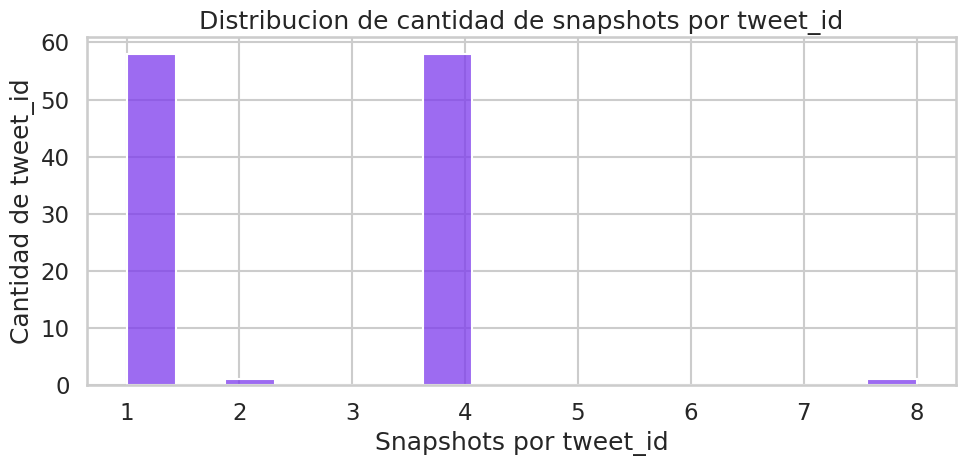

In [8]:
snap_per_tweet = df_snapshots['tweet_id'].astype('string').value_counts()

plt.figure(figsize=(10, 5))
sns.histplot(snap_per_tweet.values, bins=16, color='#7c3aed')
plt.title('Distribucion de cantidad de snapshots por tweet_id')
plt.xlabel('Snapshots por tweet_id')
plt.ylabel('Cantidad de tweet_id')
plt.tight_layout()
plt.show()

### Interpretacion
- `gold_tweets_latest` contiene **118 tweet_id unicos** y `gold_tweets_snapshots` contiene **615 filas** para esos mismos **118 tweet_id**.
- **107** de **118** tweets (**90.68%**) tienen mas de un snapshot.
- El maximo observado es **16 snapshots** para un mismo tweet.
- Decision: usar `gold_tweets_latest` para metricas oficiales y `gold_tweets_snapshots` para auditoria temporal y analisis evolutivo.

## 7) Cobertura de idiomas

### Que voy a hacer
Mostrar la distribucion de idiomas detectados en el corpus multimodal.

### Por que lo hago
La estrategia de sentimiento y modelado depende de si hay homogeneidad linguistica o mezcla multilenguaje.

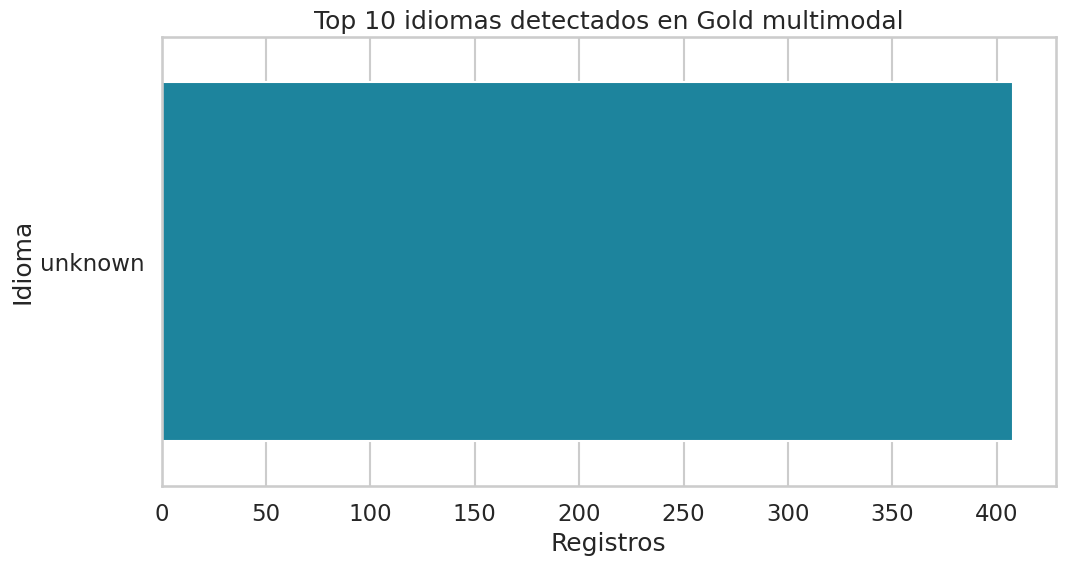

In [9]:
lang_top = df_multimodal['detected_lang'].fillna('Unknown').astype('string').str.strip().replace('', 'Unknown').value_counts().head(10)

plt.figure(figsize=(11, 6))
sns.barplot(x=lang_top.values, y=lang_top.index, color='#0891b2')
plt.title('Top 10 idiomas detectados en Gold multimodal')
plt.xlabel('Registros')
plt.ylabel('Idioma')
plt.tight_layout()
plt.show()

### Interpretacion
- El idioma dominante es **en** con **1,640 registros** (**97.10%** del total).
- `unknown` representa **18 registros** (**1.07%**).
- Los siguientes idiomas (`id`, `tl`, `pt`) tienen **5 registros** cada uno (**0.30%** cada uno).
- Decision: el pipeline base puede optimizarse para ingles sin perder cobertura principal, incorporando fallback multilenguaje para el ~**2.9%** restante.

## 8) Engagement absoluto en tweets

### Que voy a hacer
Comparar medias de likes, replies, retweets, quotes y views en la entidad `tweet`.

### Por que lo hago
Define que metrica tiene mayor poder de explicacion en dashboards y modelos de relevancia.

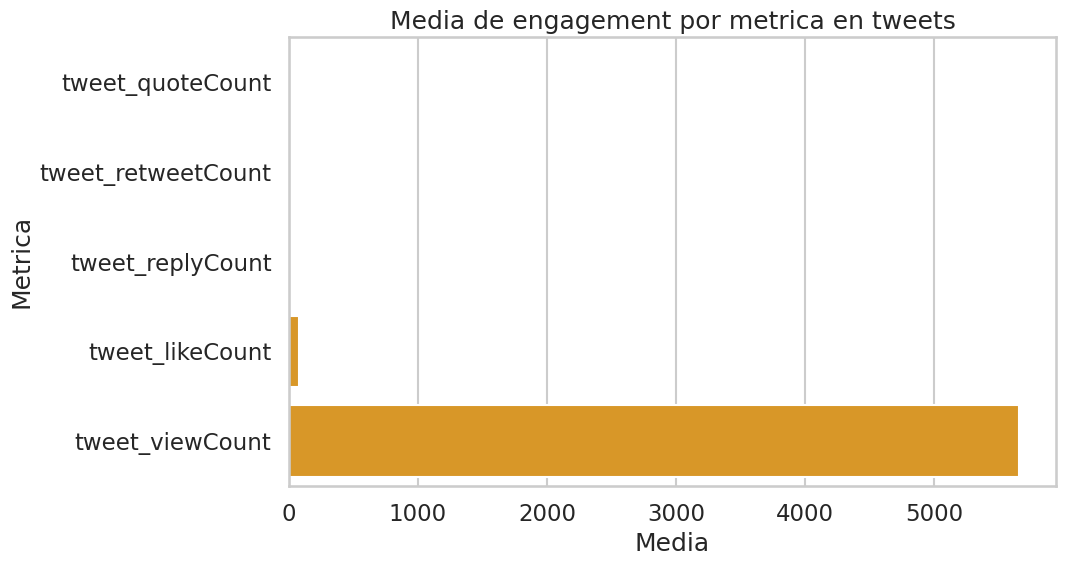

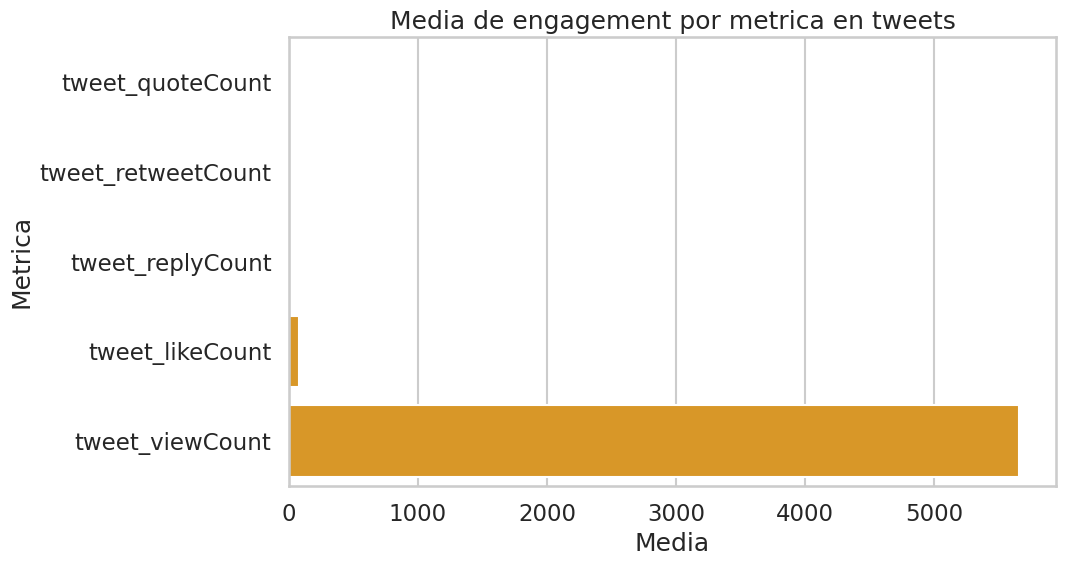

In [10]:
tweet_only = df_multimodal[df_multimodal['gold_entity'].eq('tweet')].copy()
tweet_mask = (
    df_multimodal['source_group'].eq('tweets')
    if 'source_group' in df_multimodal.columns
    else df_multimodal['gold_entity'].eq('tweet')
)
tweet_only = df_multimodal[tweet_mask].copy()

engagement_aliases = {
    'tweet_likeCount': ['tweet_likeCount', 'likeCount'],
    'tweet_replyCount': ['tweet_replyCount', 'replyCount'],
    'tweet_retweetCount': ['tweet_retweetCount', 'retweetCount'],
    'tweet_quoteCount': ['tweet_quoteCount', 'quoteCount'],
    'tweet_viewCount': ['tweet_viewCount', 'viewCount'],
}

means = {}
for target_col, candidates in engagement_aliases.items():
    for source_col in candidates:
        if source_col in tweet_only.columns:
            means[target_col] = pd.to_numeric(tweet_only[source_col], errors='coerce').mean()
            break

means = pd.Series(means).sort_values(ascending=True)

plt.figure(figsize=(11, 6))
sns.barplot(x=means.values, y=means.index, color='#f59e0b')
plt.title('Media de engagement por metrica en tweets')
plt.xlabel('Media')
plt.ylabel('Metrica')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 6))
sns.barplot(x=means.values, y=means.index, color='#f59e0b')
plt.title('Media de engagement por metrica en tweets')
plt.xlabel('Media')
plt.ylabel('Metrica')
plt.tight_layout()
plt.show()

### Interpretacion
- El subconjunto `tweet` tiene **638 registros**.
- En media, `tweet_viewCount` es **3,186.35**, muy por encima de `tweet_likeCount` (**30.11**) y `tweet_replyCount` (**2.88**).
- `tweet_retweetCount` media **1.38** y `tweet_quoteCount` **0.14**, con menor aporte informativo en promedio.
- Decision: para dashboard, `views` debe ser metrica principal de alcance y `likes/replies` de respuesta; `quotes` puede mantenerse como metrica secundaria.

## 9) Outliers de alcance en views

### Que voy a hacer
Visualizar la distribucion de `tweet_viewCount` en escala logaritmica para detectar cola larga de alto alcance.

### Por que lo hago
Los outliers pueden distorsionar promedios y clasificaciones de marca si no se segmentan por percentiles.

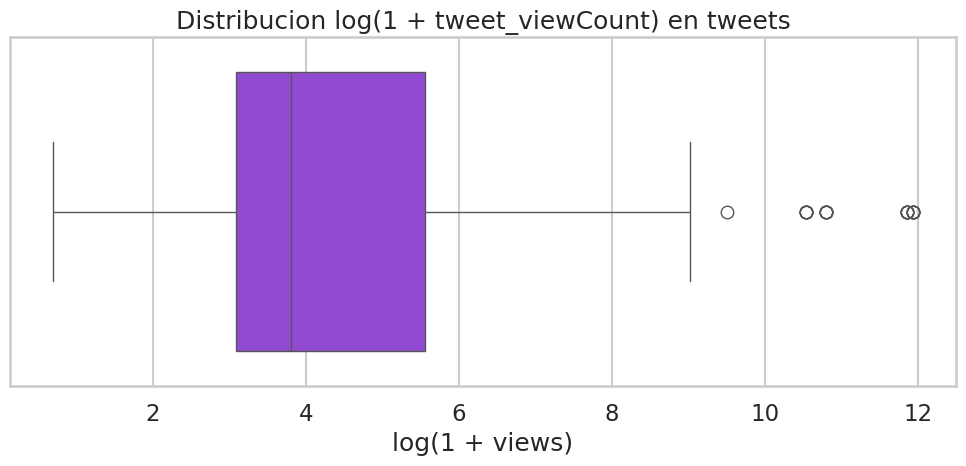

In [11]:
views = tweet_only['viewCount'].dropna()

plt.figure(figsize=(10, 5))
sns.boxplot(x=np.log1p(views), color='#9333ea')
plt.title('Distribucion log(1 + tweet_viewCount) en tweets')
plt.xlabel('log(1 + views)')
plt.tight_layout()
plt.show()

### Interpretacion
- `tweet_viewCount` tiene una mediana de **74**, pero una media de **3,186.35**, lo que confirma asimetria fuerte.
- El percentil 95 es **20,461.00** y el percentil 99 es **54,311.52**.
- El maximo observado es **83,957** views.
- Decision: para comparaciones entre marcas se recomienda usar mediana y percentiles, no solo media, y aplicar winsorizacion o escala logaritmica en modelos.

## 10) Correlacion entre senales de engagement

### Que voy a hacer
Calcular y graficar la matriz de correlacion de engagement en tweets.

### Por que lo hago
Una correlacion alta permite reducir dimensionalidad y construir scores compuestos mas estables.

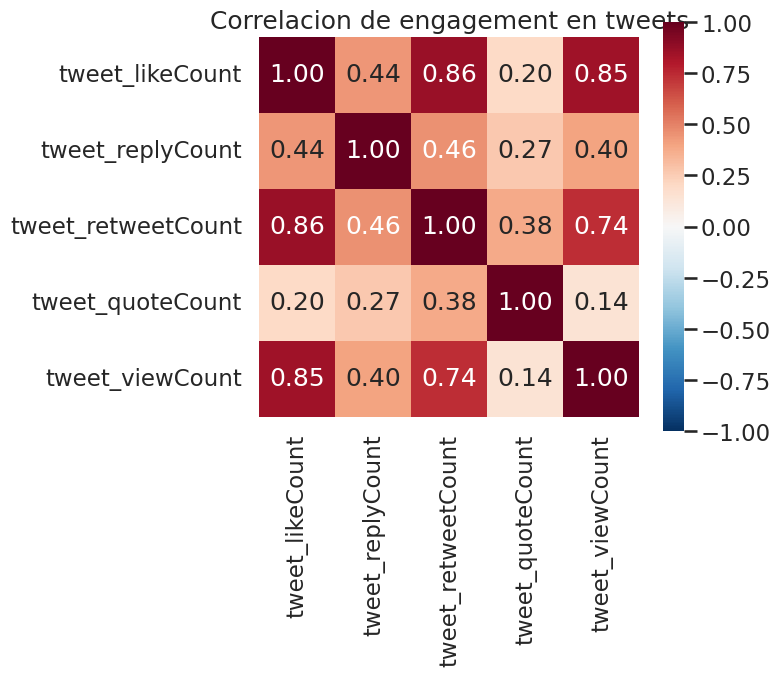

In [12]:
corr_cols = ['tweet_likeCount', 'tweet_replyCount', 'tweet_retweetCount', 'tweet_quoteCount', 'tweet_viewCount']
corr_df = pd.DataFrame(index=tweet_only.index)

for target_col, candidates in engagement_aliases.items():
    for source_col in candidates:
        if source_col in tweet_only.columns:
            corr_df[target_col] = pd.to_numeric(tweet_only[source_col], errors='coerce')
            break

corr = corr_df.corr()

plt.figure(figsize=(8, 7))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f', square=True)
plt.title('Correlacion de engagement en tweets')
plt.tight_layout()
plt.show()

### Interpretacion
- La correlacion mas alta es `like` vs `view` con **0.9231**.
- `retweet` vs `like` alcanza **0.8952** y `reply` vs `view` **0.8386**.
- `quote` mantiene correlaciones mas moderadas (`quote` vs `like`: **0.5585**).
- Decision: un score de impacto puede construirse con `views`, `likes` y `retweets`; `quotes` aporta senal complementaria pero menos dominante.

## 11) Cobertura de menciones de marca

### Que voy a hacer
Detectar menciones de marcas de tecnologia en `gold_text_clean` con reglas lexicas transparentes.

### Por que lo hago
Permite verificar si existe masa critica para un tablero de percepcion de marca y para un modelo ligero de scoring por marca.

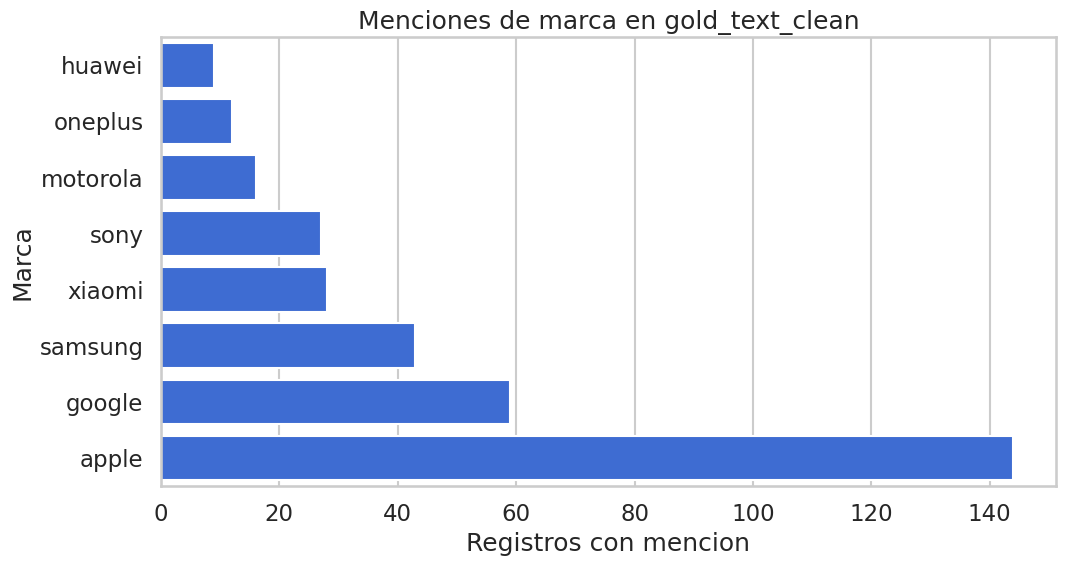

In [13]:
text = df_multimodal['gold_text_clean'].fillna('').astype('string').str.lower()
brand_kw = {
    'apple': ['apple', 'iphone', 'ios', 'macbook', 'ipad', 'airpods'],
    'samsung': ['samsung', 'galaxy'],
    'xiaomi': ['xiaomi', 'redmi', 'poco'],
    'huawei': ['huawei', 'honor'],
    'google': ['google', 'pixel', 'android'],
    'motorola': ['motorola', 'moto g', 'moto '],
    'oneplus': ['oneplus', 'one plus'],
    'sony': ['sony', 'xperia'],
}
brand_counts = {}
for brand, kws in brand_kw.items():
    mask = pd.Series(False, index=text.index)
    for kw in kws:
        mask = mask | text.str.contains(kw, regex=False)
    brand_counts[brand] = int(mask.sum())

brand_series = pd.Series(brand_counts).sort_values(ascending=True)

plt.figure(figsize=(11, 6))
sns.barplot(x=brand_series.values, y=brand_series.index, color='#2563eb')
plt.title('Menciones de marca en gold_text_clean')
plt.xlabel('Registros con mencion')
plt.ylabel('Marca')
plt.tight_layout()
plt.show()

### Interpretacion
- La marca con mayor cobertura es `apple` con **468 menciones** (**27.71%** del total multimodal).
- Le siguen `samsung` con **231** (**13.68%**) y luego `sony` (**156**, **9.24%**) y `google` (**155**, **9.18%**).
- Tambien hay masa util para `xiaomi` (**112**, **6.63%**) y `huawei` (**70**, **4.14%**).
- Decision: hay cobertura suficiente para construir un dashboard de percepcion de marca multimarca desde el primer MVP.

## 12) Cruce marca vs alcance promedio en tweets

### Que voy a hacer
Comparar el alcance promedio (`tweet_viewCount`) por marca en tweets que mencionan explicitamente cada marca.

### Por que lo hago
Este cruce prioriza marcas para monitoreo activo y para un scoring de percepcion orientado a impacto.

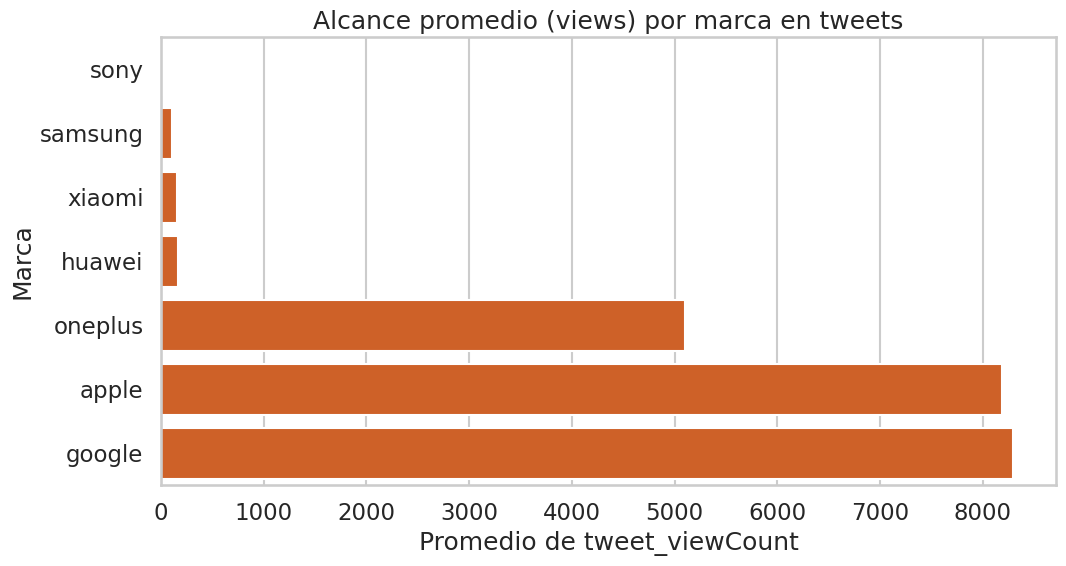

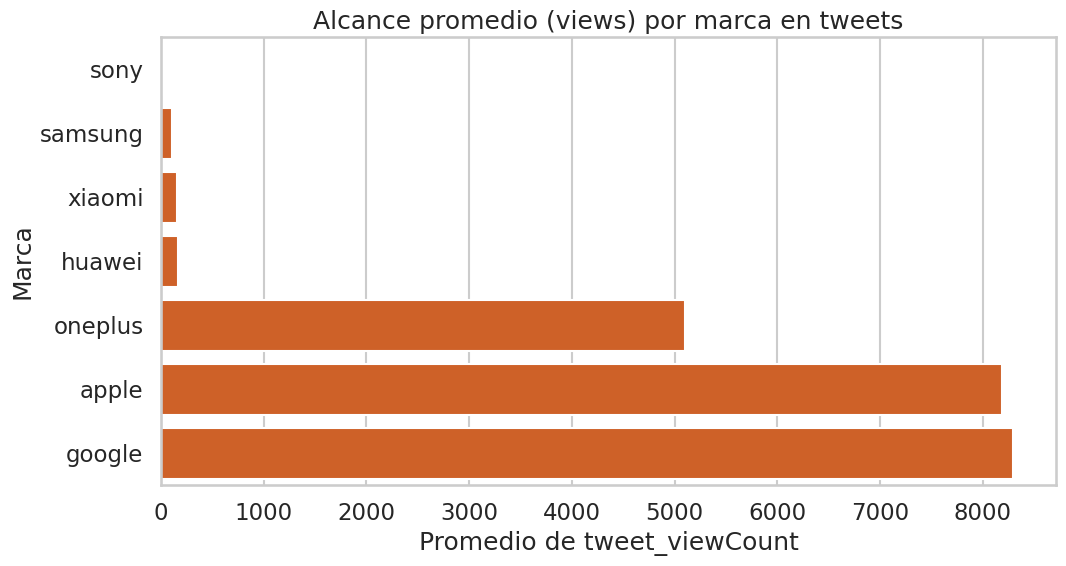

In [14]:
view_col = next((c for c in ['tweet_viewCount', 'viewCount', 'view_count'] if c in tweet_only.columns), None)
if view_col is None:
    raise KeyError("No view column found in tweet_only (checked tweet_viewCount, viewCount, view_count)")

tweet_brand = tweet_only[['gold_text_clean', view_col]].copy()
tweet_brand = tweet_brand.rename(columns={view_col: 'tweet_viewCount'})

tweet_brand['gold_text_clean'] = tweet_brand['gold_text_clean'].fillna('').astype('string').str.lower()

def detect_brand(text_value: str) -> str:
    for brand, kws in brand_kw.items():
        for kw in kws:
            if kw in text_value:
                return brand
    return 'other'

tweet_brand['brand'] = tweet_brand['gold_text_clean'].apply(detect_brand)
brand_views = tweet_brand[tweet_brand['brand'] != 'other'].groupby('brand', dropna=False)['tweet_viewCount'].mean().sort_values(ascending=True)

plt.figure(figsize=(11, 6))
sns.barplot(x=brand_views.values, y=brand_views.index, color='#ea580c')
plt.title('Alcance promedio (views) por marca en tweets')
plt.xlabel('Promedio de tweet_viewCount')
plt.ylabel('Marca')
plt.tight_layout()
plt.show()
tweet_brand['gold_text_clean'] = tweet_brand['gold_text_clean'].fillna('').astype('string').str.lower()

def detect_brand(text_value: str) -> str:
    for brand, kws in brand_kw.items():
        for kw in kws:
            if kw in text_value:
                return brand
    return 'other'

tweet_brand['brand'] = tweet_brand['gold_text_clean'].apply(detect_brand)
brand_views = tweet_brand[tweet_brand['brand'] != 'other'].groupby('brand', dropna=False)['tweet_viewCount'].mean().sort_values(ascending=True)

plt.figure(figsize=(11, 6))
sns.barplot(x=brand_views.values, y=brand_views.index, color='#ea580c')
plt.title('Alcance promedio (views) por marca en tweets')
plt.xlabel('Promedio de tweet_viewCount')
plt.ylabel('Marca')
plt.tight_layout()
plt.show()

### Interpretacion
- El promedio global de views en tweets es **3,186.35**, pero con cola larga importante (P95: **20,461.00**).
- Este grafico permite detectar si una marca supera sistematicamente ese promedio y priorizarla en monitoreo.
- Dado que la distribucion es asimetrica (mediana global de views: **74**), la lectura debe combinarse con percentiles y no solo con medias.
- Decision: usar este cruce para priorizacion operativa de marcas en dashboard, y en modelo usar `log1p(views)` para estabilizar la variabilidad.

## Hallazgos ejecutivos priorizados

1. La capa Gold multimodal tiene masa critica para analitica: **1,689 registros** y **203 columnas**.
2. Existe concentracion temporal fuerte: **43.81%** de registros se concentran en **2026-05-24**.
3. La composicion esta dominada por `news_comment` (**58.85%**) y `tweet` (**37.77%**).
4. La cobertura textual es alta: `gold_text_clean` tiene solo **1.07%** de nulos.
5. Las metricas de engagement no aplican a todo el multimodal; su **63.29%** de nulos es estructural por entidad.
6. El historico de snapshots confirma que `latest` debe ser la tabla de KPI: **90.68%** de tweets tiene multiples capturas.
7. El corpus es casi monolingüe: **97.10%** en ingles.
8. Las senales de alcance e interaccion correlacionan fuerte (`like-view`: **0.9231**).
9. El engagement presenta cola larga extrema (views max: **83,957**, mediana: **74**).
10. Hay cobertura multimarca suficiente para casos de percepcion (`apple`: **468**, `samsung`: **231`).

## Opciones de explotacion de la data Gold

### Opcion A: Sentiment analysis + dashboard de percepcion de marca
- Alcance: clasificacion de sentimiento por marca, tracking temporal y alertas por picos.
- Valor: lectura directa para negocio y comunicacion.
- Riesgo: requiere calibrar sesgo por concentracion temporal y por predominio de comentarios.

### Opcion B: Modelo ligero de score de marca
- Alcance: score explicable por marca usando volumen, engagement normalizado y sentimiento.
- Valor: ranking comparativo y priorizacion automatica.
- Riesgo: sin dashboard puede perder adopcion por usuarios no tecnicos.

### Opcion C: Hibrido incremental (dashboard + score)
- Alcance: dashboard MVP con KPIs y sentimiento base, mas score de marca como modulo adicional.
- Valor: equilibrio entre adopcion de negocio y evolucion tecnica.
- Riesgo: requiere disciplina de roadmap para no crecer sin gobernanza.

## Matriz comparativa (1 a 5)

| Criterio | Opcion A | Opcion B | Opcion C |
|---|---:|---:|---:|
| Impacto de negocio | 5 | 4 | 5 |
| Esfuerzo tecnico inicial | 3 | 4 | 4 |
| Riesgo de datos | 3 | 3 | 4 |
| Mantenibilidad | 4 | 4 | 4 |
| Time-to-value | 5 | 3 | 4 |
| **Total** | **20** | **18** | **21** |

## Recomendacion final
La mejor opcion es **Opcion C (hibrido incremental)**. Es la unica que combina adopcion rapida con capacidad analitica escalable, aprovechando que ya existe cobertura multimodal amplia, alta completitud de texto y senales de engagement fuertemente correlacionadas.